In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

data_path = '/kaggle/input/datasets/tushaamagrawal/icbhi-2017-challenge/ICBHI_final_database'

total_files = os.listdir(data_path)

print("Total files are:",len(total_files))

# we would check now to see if no. of .wav and .txt files are matching or not

wav_files = [f for f in total_files if f.endswith(".wav")]
txt_files = [f for f in total_files if f.endswith(".txt")]

print("Total .wav files:",len(wav_files))  #920
print("Total .txt files:",len(txt_files))  #922

#so mismatch is there, we need to use only those which have both .wav and .txt

wav_set = set([f.replace(".wav", "") for f in wav_files])
txt_set = set([f.replace(".txt","") for f in txt_files])

common_files = list(wav_set.intersection(txt_set))

print("Usable files:", len(common_files))

missing_txt = wav_set - txt_set
missing_wav = txt_set - wav_set

print("Total wav files without txt files:",missing_txt)
print("Total txt files without wav files:",missing_wav)

2026-05-31 15:42:48.824274: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780242169.025740      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780242169.081157      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780242169.558124      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780242169.558163      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780242169.558165      57 computation_placer.cc:177] computation placer alr

Total files are: 1843
Total .wav files: 920
Total .txt files: 922
Usable files: 920
Total wav files without txt files: set()
Total txt files without wav files: {'filename_format', 'filename_differences'}


In [3]:
train_files, test_files = train_test_split(common_files, test_size=0.2, random_state=42)
train_files, val_files  = train_test_split(train_files, test_size=0.2, random_state=42)

In [4]:
def add_noise(signal):
    noise = np.random.randn(len(signal))
    return signal + 0.005 * noise

def time_shift(signal):
    shift = int(np.random.uniform(-0.2, 0.2) * len(signal))
    return np.roll(signal, shift)

def volume_scale(signal):
    return signal * np.random.uniform(0.8, 1.2)

In [5]:
def augment_signal(signal):
    return [
        signal,
        add_noise(signal),
        time_shift(signal),
        volume_scale(signal)
    ]

In [6]:
def build_train_segments(file_list):
    segments = []
    labels = []

    for file in file_list:
        audio_path = f"{data_path}/{file}.wav"
        text_path  = f"{data_path}/{file}.txt"

        y, sr = librosa.load(audio_path, sr=16000)

        with open(text_path, "r") as f:
            for line in f:
                start, end, crackle, wheeze = line.strip().split()

                start, end = float(start), float(end)
                crackle, wheeze = int(crackle), int(wheeze)

                segment = y[int(start*sr):int(end*sr)]

                if len(segment) < 1000:
                    continue

                # 4-class
                if crackle==0 and wheeze==0:
                    label=0
                elif crackle==1 and wheeze==0:
                    label=1
                elif crackle==0 and wheeze==1:
                    label=2
                else:
                    label=3

                aug_list = augment_signal(segment)

                for aug in aug_list:
                    segments.append(aug)
                    labels.append(label)

    return segments, labels

In [7]:
def build_segments_with_ids(file_list):
    segments = []
    labels = []
    file_ids = []

    for file in file_list:
        audio_path = f"{data_path}/{file}.wav"
        text_path  = f"{data_path}/{file}.txt"

        y, sr = librosa.load(audio_path, sr=16000)

        with open(text_path, "r") as f:
            for line in f:
                start, end, crackle, wheeze = line.strip().split()

                start, end = float(start), float(end)
                crackle, wheeze = int(crackle), int(wheeze)

                segment = y[int(start*sr):int(end*sr)]

                if len(segment) < 1000:
                    continue

                if crackle==0 and wheeze==0:
                    label=0
                elif crackle==1 and wheeze==0:
                    label=1
                elif crackle==0 and wheeze==1:
                    label=2
                else:
                    label=3

                segments.append(segment)
                labels.append(label)
                file_ids.append(file)

    return segments, labels, file_ids

In [8]:
def to_spec(seg):
    mel = librosa.feature.melspectrogram(y=seg, sr=16000, n_mels=128)
    return librosa.power_to_db(mel)

def pad_specs(spec, target=128):
    if spec.shape[1] < target:
        pad = target - spec.shape[1]
        spec = np.pad(spec, ((0,0),(0,pad)))
    else:
        spec = spec[:, :target]
    return spec

In [10]:
import zipfile
from collections import defaultdict
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
train_seg, train_lbl = build_train_segments(train_files)

X_train = []
y_train = []

for seg, lbl in zip(train_seg, train_lbl):
    spec = pad_specs(to_spec(seg))
    X_train.append(spec)
    y_train.append(lbl)

X_train = np.array(X_train)[..., np.newaxis]
y_train = np.array(y_train)

In [11]:
val_seg, val_lbl, _ = build_segments_with_ids(val_files)

X_val = []
y_val = []

for seg, lbl in zip(val_seg, val_lbl):
    spec = pad_specs(to_spec(seg))
    X_val.append(spec)
    y_val.append(lbl)

X_val = np.array(X_val)[..., np.newaxis]
y_val = np.array(y_val)

In [12]:
test_seg, test_lbl, test_ids = build_segments_with_ids(test_files)

X_test = []
y_test = []
valid_ids = []

for seg, lbl, fid in zip(test_seg, test_lbl, test_ids):
    spec = pad_specs(to_spec(seg))
    X_test.append(spec)
    y_test.append(lbl)
    valid_ids.append(fid)

X_test = np.array(X_test)[..., np.newaxis]
y_test = np.array(y_test)
test_ids = valid_ids

In [13]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,1)),
    MaxPooling2D((2,2)),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(4, activation='softmax')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

I0000 00:00:1780242723.818143      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780242723.823946      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [14]:
cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50


I0000 00:00:1780242730.465400     142 service.cc:152] XLA service 0x7a05a4012440 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780242730.465453     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780242730.465460     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780242730.979588     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/542 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.4160 - loss: 1.8220

I0000 00:00:1780242735.745646     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


542/542 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.5208 - loss: 1.2039 - val_accuracy: 0.5483 - val_loss: 1.0834
Epoch 2/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.6047 - loss: 0.9222 - val_accuracy: 0.5598 - val_loss: 1.0629
Epoch 3/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.6801 - loss: 0.7423 - val_accuracy: 0.5861 - val_loss: 1.1063
Epoch 4/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.7476 - loss: 0.5945 - val_accuracy: 0.5782 - val_loss: 1.1315
Epoch 5/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8290 - loss: 0.4358 - val_accuracy: 0.5835 - val_loss: 1.2751
Epoch 6/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8900 - loss: 0.3038 - val_accuracy: 0.5764 - val_loss: 1.5100
Epoch 7/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9188 - loss: 0.2209 - val_accuracy: 0.5984 - val_loss: 1.4695
Epoch 8/50
542/542 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9415 - loss: 0.1653 - val_accurac

In [15]:
y_pred_prob = cnn_model.predict(X_test)

from collections import defaultdict

file_preds = defaultdict(list)
file_true_map = defaultdict(list)

for prob, label, fid in zip(y_pred_prob, y_test, test_ids):
    file_preds[fid].append(prob)
    file_true_map[fid].append(label)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [16]:
y_true_file = []
y_pred_file = []

for fid in file_preds:

    probs = np.array(file_preds[fid])

    # TRUE label = majority
    true_label = max(set(file_true_map[fid]), key=file_true_map[fid].count)

    # aggregation
    conf = np.max(probs, axis=1)
    k = max(1, len(probs)//3)
    top_idx = np.argsort(conf)[-k:]

    top_probs = probs[top_idx]
    top_conf  = conf[top_idx]

    weights = top_conf / np.sum(top_conf)

    final_prob = np.sum(top_probs * weights[:, None], axis=0)
    pred = np.argmax(final_prob)

    y_true_file.append(true_label)
    y_pred_file.append(pred)

In [17]:
print("CNN File Accuracy:", accuracy_score(y_true_file, y_pred_file))
print("Macro F1:", f1_score(y_true_file, y_pred_file, average='macro'))

print("\nReport:\n", classification_report(y_true_file, y_pred_file))

CNN File Accuracy: 0.6358695652173914
Macro F1: 0.5580195722556078

Report:
               precision    recall  f1-score   support

           0       0.69      0.74      0.71        94
           1       0.57      0.63      0.60        51
           2       0.56      0.40      0.47        25
           3       0.62      0.36      0.45        14

    accuracy                           0.64       184
   macro avg       0.61      0.53      0.56       184
weighted avg       0.63      0.64      0.63       184



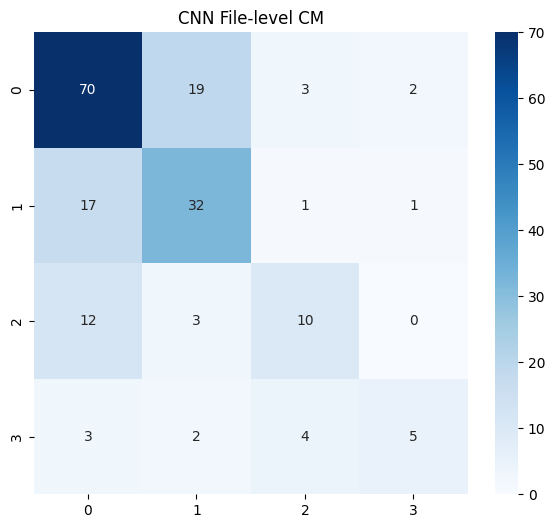

In [18]:
cm = confusion_matrix(y_true_file, y_pred_file)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues')
plt.title("CNN File-level CM")
plt.show()

In [21]:
cnn_model.save("Aero_CNN.keras")